In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
# Load dataset directly from UCI repository

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/letter-recognition/letter-recognition.data"

# Column names
columns = ['letter',
           'x-box', 'y-box', 'width', 'height',
           'onpix', 'x-bar', 'y-bar', 'x2bar',
           'y2bar', 'xybar', 'x2ybr', 'xy2br',
           'x-ege', 'xegvy', 'y-ege', 'yegvx']

# Read dataset
dataset = pd.read_csv(url, header=None, names=columns)

print(dataset.head())

# Features and labels
X = dataset.drop('letter', axis=1)
y = dataset['letter']

print("\nDataset Shape:", X.shape)
print("Classes:", sorted(y.unique()))

  letter  x-box  y-box  width  height  onpix  x-bar  y-bar  x2bar  y2bar  \
0      T      2      8      3       5      1      8     13      0      6   
1      I      5     12      3       7      2     10      5      5      4   
2      D      4     11      6       8      6     10      6      2      6   
3      N      7     11      6       6      3      5      9      4      6   
4      G      2      1      3       1      1      8      6      6      6   

   xybar  x2ybr  xy2br  x-ege  xegvy  y-ege  yegvx  
0      6     10      8      0      8      0      8  
1     13      3      9      2      8      4     10  
2     10      3      7      3      7      3      9  
3      4      4     10      6     10      2      8  
4      6      5      9      1      7      5     10  

Dataset Shape: (20000, 16)
Classes: ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']


In [3]:
# Encode labels A-Z → 0-25

le = LabelEncoder()

y_encoded = le.fit_transform(y)

# One-hot encoding
y_onehot = keras.utils.to_categorical(y_encoded, num_classes=26)

# Scale features
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [4]:
x_train, x_test, y_train, y_test, ye_train, ye_test = train_test_split(
    X_scaled,
    y_onehot,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print("Training samples:", x_train.shape[0])
print("Testing samples :", x_test.shape[0])

Training samples: 16000
Testing samples : 4000


In [5]:
model = Sequential()

model.add(Dense(256, activation='relu',
                input_shape=(x_train.shape[1],)))

model.add(Dropout(0.3))

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(64, activation='relu'))

model.add(Dense(26, activation='softmax'))

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,194 (184.35 KB)

 Trainable params: 47,194 (184.35 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [7]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    x_train,
    y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop]
)

Epoch 1/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4484 - loss: 1.9142 - val_accuracy: 0.7322 - val_loss: 0.9324
Epoch 2/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6860 - loss: 0.9993 - val_accuracy: 0.7903 - val_loss: 0.7012
Epoch 3/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7409 - loss: 0.8128 - val_accuracy: 0.8309 - val_loss: 0.5693
Epoch 4/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7738 - loss: 0.6998 - val_accuracy: 0.8556 - val_loss: 0.4934
Epoch 5/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7984 - loss: 0.6323 - val_accuracy: 0.8647 - val_loss: 0.4568
Epoch 6/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8176 - loss: 0.5721 - val_accuracy: 0.8866 - val_loss: 0.4054
Epoch 7/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8324 - loss: 0.5296 - val_accuracy: 0.8841 - val_loss: 0.3818
Epoch 8/30
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8398 - loss: 0.4963 - val_accuracy: 0.

In [8]:
loss, acc = model.evaluate(x_test, y_test)

print(f"\nTest Accuracy : {acc*100:.2f}%")
print(f"Test Loss     : {loss:.4f}")

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9538 - loss: 0.1452

Test Accuracy : 95.38%
Test Loss     : 0.1452


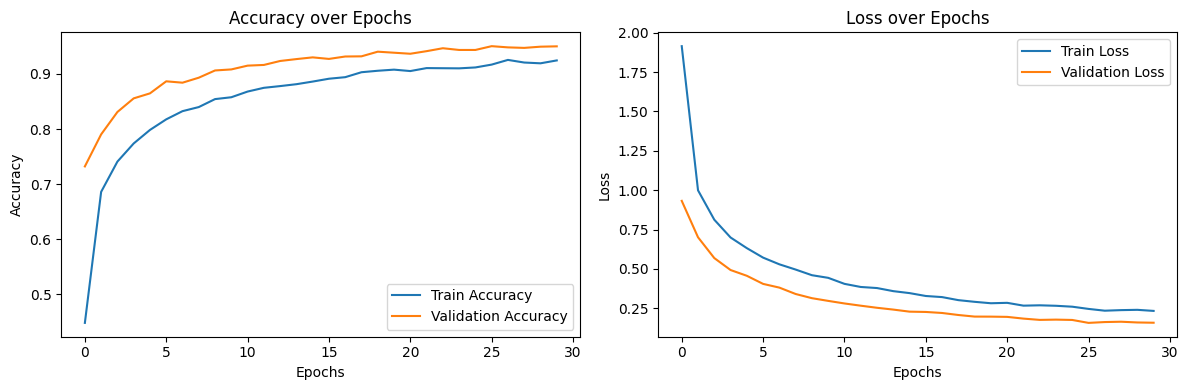

In [9]:
plt.figure(figsize=(12,4))

# Accuracy
plt.subplot(1,2,1)

plt.plot(history.history['accuracy'],
         label='Train Accuracy')

plt.plot(history.history['val_accuracy'],
         label='Validation Accuracy')

plt.title('Accuracy over Epochs')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend()

# Loss
plt.subplot(1,2,2)

plt.plot(history.history['loss'],
         label='Train Loss')

plt.plot(history.history['val_loss'],
         label='Validation Loss')

plt.title('Loss over Epochs')

plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend()

plt.tight_layout()
plt.show()

125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


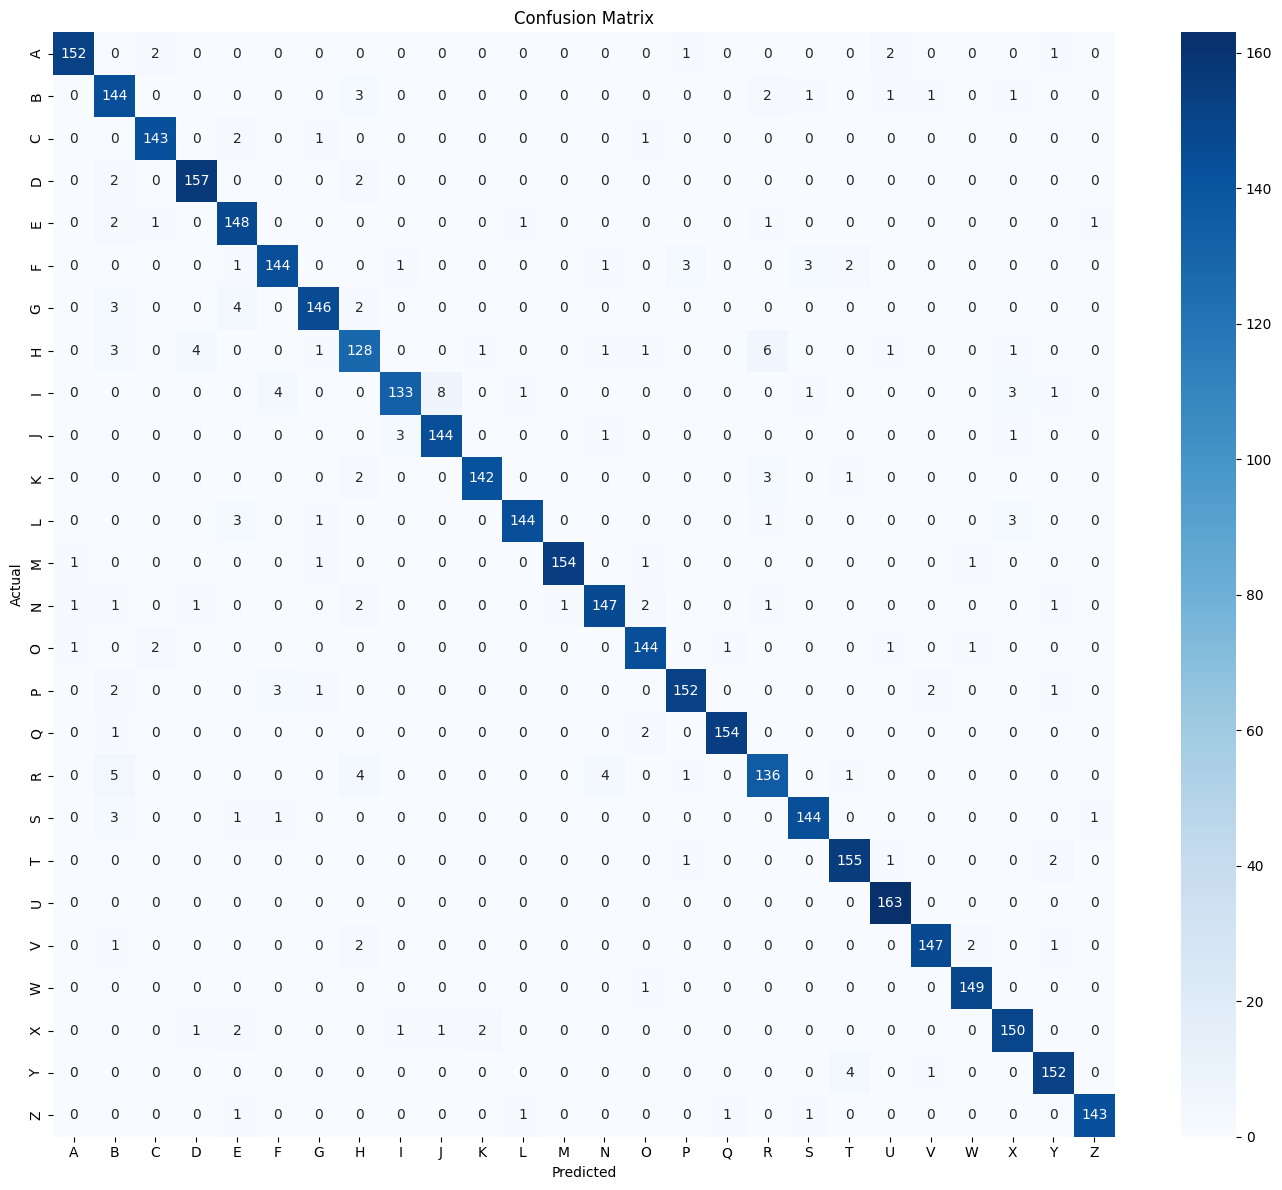

In [10]:
y_pred = model.predict(x_test)

y_pred_enc = np.argmax(y_pred, axis=1)

cm = confusion_matrix(ye_test, y_pred_enc)

plt.figure(figsize=(14,12))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.show()

In [11]:
print("\nClassification Report:\n")

print(
    classification_report(
        ye_test,
        y_pred_enc,
        target_names=le.classes_
    )
)


Classification Report:

              precision    recall  f1-score   support

           A       0.98      0.96      0.97       158
           B       0.86      0.94      0.90       153
           C       0.97      0.97      0.97       147
           D       0.96      0.98      0.97       161
           E       0.91      0.96      0.94       154
           F       0.95      0.93      0.94       155
           G       0.97      0.94      0.95       155
           H       0.88      0.87      0.88       147
           I       0.96      0.88      0.92       151
           J       0.94      0.97      0.95       149
           K       0.98      0.96      0.97       148
           L       0.98      0.95      0.96       152
           M       0.99      0.97      0.98       158
           N       0.95      0.94      0.95       157
           O       0.95      0.96      0.95       150
           P       0.96      0.94      0.95       161
           Q       0.99      0.98      0.98       157
  

In [12]:
print("\nSample Predictions:")

print(f"{'#':<5} {'Actual':>8} {'Predicted':>12}")

print("-"*30)

for i in range(5):

    actual = le.classes_[ye_test[i]]

    pred = le.classes_[y_pred_enc[i]]

    print(f"{i:<5} {actual:>8} {pred:>12}")


Sample Predictions:
#       Actual    Predicted
------------------------------
0            R            R
1            M            M
2            B            B
3            P            P
4            J            J
